In [9]:
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from settings import load_settings

from capstone import construct_final_dataset as fd

In [10]:
sns.set_theme(style="ticks")

In [11]:
SETTINGS = load_settings()
ALL_PREDICTOR_VARIABLES = [
    fd.P_BINARY_ARTIFACTS,
    fd.P_BRANCH_PROTECTION,
    fd.P_CI_TESTS,
    fd.P_CII_BEST_PRACTICES,
    fd.P_CODE_REVIEW,
    fd.P_CONTRIBUTORS,
    fd.P_DANGEROUS_WORKFLOW,
    fd.P_DEPENDENCY_UPDATE_TOOL,
    fd.P_FUZZING,
    fd.P_LICENSE,
    fd.P_MAINTAINED,
    fd.P_PACKAGING,
    fd.P_PINNED_DEPENDENCIES,
    fd.P_SAST,
    fd.P_SECURITY_POLICY,
    fd.P_SIGNED_RELEASES,
    fd.P_TOKEN_PERMISSIONS,
]
FEATURE_COLUMNS = fd.ALL_CONTROL_VARIABLES + ALL_PREDICTOR_VARIABLES

In [12]:
final_df = pl.read_parquet(SETTINGS.final_dataset_path)

In [13]:
final_df.shape

(46779, 29)

In [14]:
final_df.head()

package_name,github_repo,package_dependency_count,package_total_downloads,github_repo_age_in_years,github_repo_commit_staleness_in_days,github_repo_contributions_count,github_repo_size_in_kb,aggregated_score,binary_artifacts,branch_protection,ci_tests,cii_best_practices,code_review,contributors,dangerous_workflow,dependency_update_tool,fuzzing,license,maintained,packaging,pinned_dependencies,static_analysis_tools,security_policy,signed_releases,token_permissions,vul_count,mttu,mttr
str,str,u32,i64,f64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64
"""babel""","""python-babel/babel""",1,987553491,12.7,26,152,3422,5.7,10,-1,null,0,5,null,10,null,10,10,10,10,0,0,0,0,0,null,0.0,0.0
"""microfilter""","""microprediction/microfilter""",9,2347,5.5,918,2,254326,2.8,10,0,-1,0,0,0,10,0,0,0,0,-1,0,0,0,-1,0,0,null,null
"""ckanext-toolbelt""","""datashades/ckanext-toolbelt""",5,57003,4.61,54,2,669,2.7,10,0,0,0,1,10,10,0,0,0,1,10,0,0,0,-1,0,23,12.54614,0.0
"""square-auth""","""ukp-square/square-auth""",3,3786,4.08,728,2,137,2.4,10,0,0,0,0,6,10,0,0,10,0,-1,0,0,0,-1,0,9,0.0,0.0
"""py-console""","""mike-huls/py-console""",1,64918,4.42,1084,1,147,1.5,10,0,-1,0,0,0,-1,0,0,10,0,-1,-1,0,0,-1,-1,17,null,null


## Spearman Correlation Matrix

In [15]:
def plot_spearman_correlation_matrix(data: pl.DataFrame, feature_columns: list[str] = None):
    """Plots a Spearman correlation matrix using Seaborn.

    Parameters:
    - data: A Polars DataFrame containing the data.
    - feature_columns: A list of column names to include in the correlation matrix.
    """
    df = data.select(feature_columns).to_pandas()

    # Sort alphabetically and strip 'github_repo_' and 'package_' prefixes from column names
    df.columns = sorted([
        col.removeprefix("github_repo_").removeprefix("package_")
        for col in df.columns
    ])

    corr_matrix = df.corr(method='spearman')

    # Create a mask for the upper triangle
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    fig, ax = plt.subplots(figsize=(18, 14))

    sns.heatmap(
        corr_matrix, 
        mask=mask,
        annot=True, 
        vmin=-1,
        center=0,  
        vmax=1, 
        square=True,
        cmap='coolwarm',
        cbar=True,                # Show color bar
        fmt='.2f',
        linewidths=0,             # No global grid lines
        cbar_kws={'shrink': .8},  # Adjust color bar size
        ax=ax,
    )

    # Draw lines only on the visible (lower triangle) cells
    n = len(corr_matrix)
    for i in range(n):
        for j in range(i):
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', linewidth=0.5))

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)  
    #plt.title('Spearman Correlation Matrix Heatmap of Predictor Variables', fontsize=16)
    plt.tight_layout()
    plt.savefig(f"{SETTINGS.visualizations_path}/spearman_correlation_matrix.pdf", bbox_inches="tight") 
    plt.show()


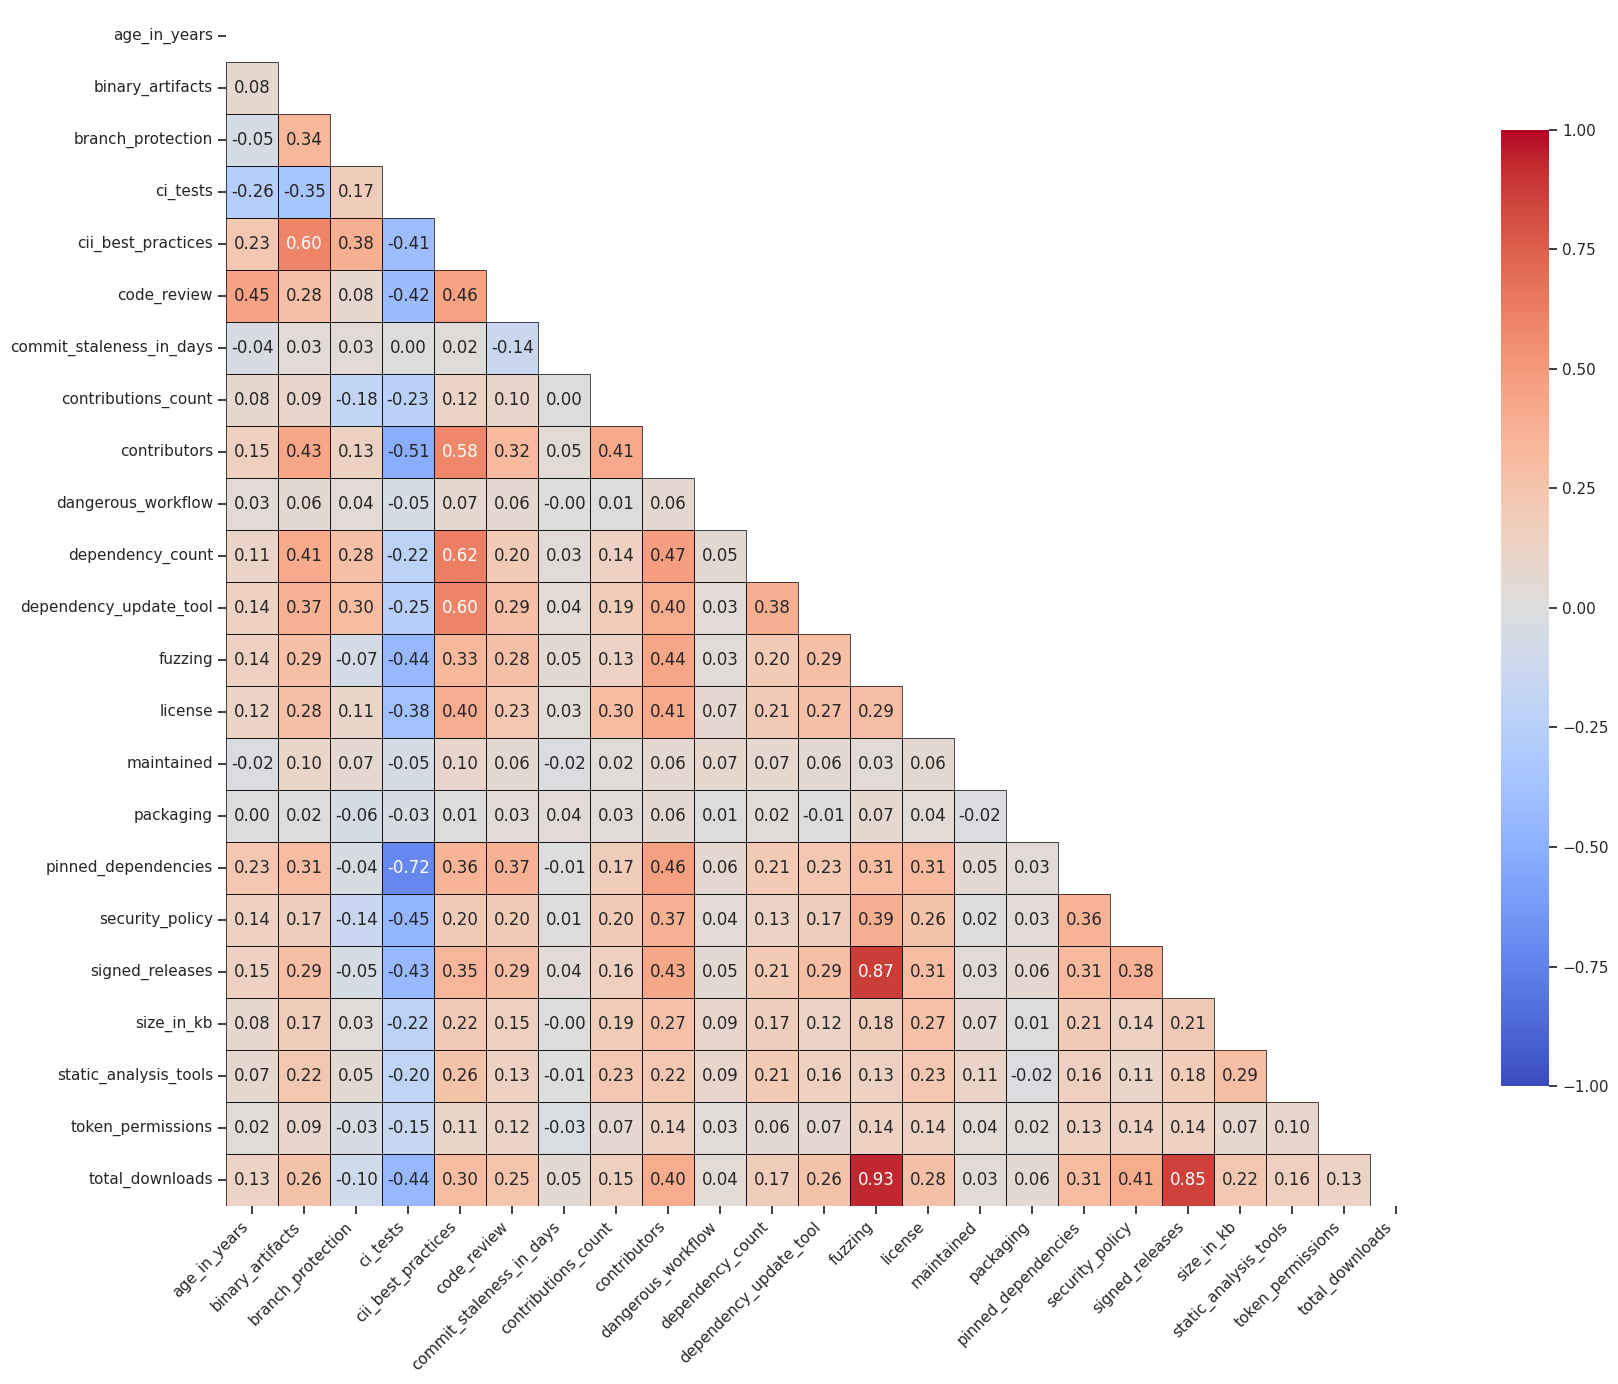

In [16]:
plot_spearman_correlation_matrix(final_df, feature_columns=FEATURE_COLUMNS)